<a href="https://colab.research.google.com/github/25wh1a0518/NASSCOM/blob/main/WEEK_3/U6_Probability_Statistics_Part2_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


In [ ]:
rolls = np.random.randint(1, 7, size=100_000)

p_even = (rolls % 2 == 0).mean()
p_gt4  = (rolls > 4).mean()
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(even) ~ 0.499  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)
P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [ ]:
flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)
# 1. P(both heads)  -> heads == 2
p_both_heads = (heads == 2).mean()
print('P(both heads) ~', round(p_both_heads, 3), ' (true 1/4)')

# 2. P(at least one head)  -> heads >= 1
p_at_least_one_head = (heads >= 1).mean()
print('P(at least one head) ~', round(p_at_least_one_head, 3), ' (true 3/4)')

# 3. Do P(0) + P(1) + P(2) sum to 1?
print('P(0) + P(1) + P(2) =', round(p_both_heads + p_at_least_one_head, 3))

P(both heads) ~ 0.248  (true 1/4)
P(at least one head) ~ 0.75  (true 3/4)
P(0) + P(1) + P(2) = 0.998


In [ ]:
rolls = np.random.randint(1, 7, size=100_000)

even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))



P(6 | even) ~ 0.332  (true 1/3)
P(A)      = 0.5
P(A | B)  = 0.665
Independent? False


In [ ]:
rolls = np.random.randint(1, 7, size=100_000)

# 1. P(odd | roll < 4)  -> condition on rolls < 4, then check odd
odd_rolls = rolls[rolls % 2 == 1]
p_odd_given_lt4 = (odd_rolls < 4).mean()

# 2. P(roll < 4)
p_lt4 = (rolls < 4).mean()

# 3. Compare P(odd | <4) with P(odd) overall — independent?
print('P(odd | roll < 4) ~', round(p_odd_given_lt4, 3), ' (true 1/3)')

P(odd | roll < 4) ~ 0.664  (true 1/3)


In [ ]:
p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01

p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

# Bayes: P(D | +)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [ ]:
N = 1_000_000
has_disease = np.random.rand(N) < p_disease
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)

among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))


Simulated P(sick | positive) = 0.507


In [ ]:
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

# 2. P('free') via total probability
p_free = p_free_given_spam * p_spam + p_free_given_ham * (1 - p_spam)
print('P(free) ~', round(p_free, 3))

# 3. Bayes: P(spam | 'free')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print('P(spam | free) ~', round(p_spam_given_free, 3))


P(free) ~ 0.16
P(spam | free) ~ 0.75


In [2]:
import scipy.stats as stats

bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.298 (true 0.3)
Poisson(4) mean ~ 3.996 (true 4)


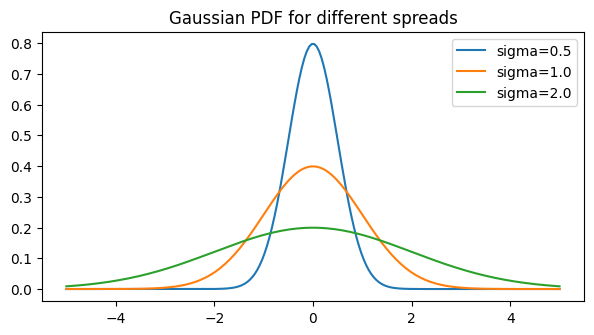

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()


Sample mean: 2.0244


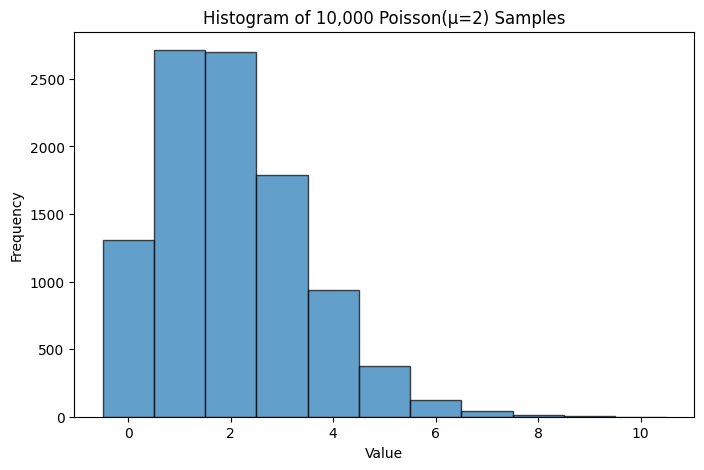

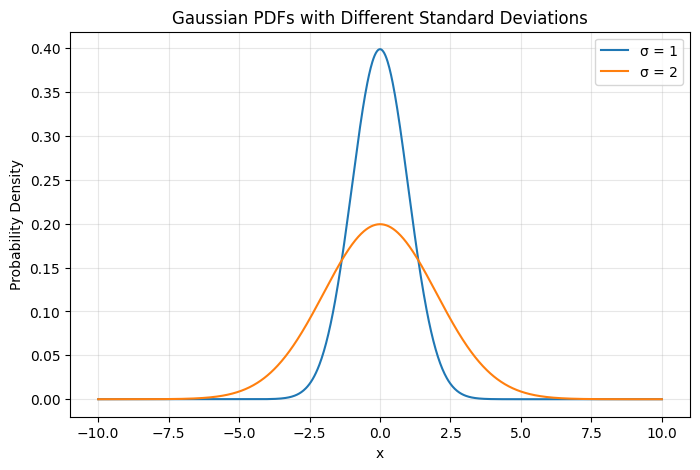

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Poisson(mu=2) samples + mean
samples = np.random.poisson(lam=2, size=10000)

sample_mean = np.mean(samples)
print("Sample mean:", sample_mean)

# 2. Histogram of the samples
plt.figure(figsize=(8, 5))
plt.hist(samples, bins=np.arange(-0.5, samples.max() + 1.5, 1),
         edgecolor="black", alpha=0.7)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of 10,000 Poisson(μ=2) Samples")
plt.show()

# 3. Gaussian PDF for two different sigmas
x = np.linspace(-10, 10, 1000)

mu = 0
sigma1 = 1
sigma2 = 2

pdf1 = norm.pdf(x, loc=mu, scale=sigma1)
pdf2 = norm.pdf(x, loc=mu, scale=sigma2)

plt.figure(figsize=(8, 5))
plt.plot(x, pdf1, label="σ = 1")
plt.plot(x, pdf2, label="σ = 2")

plt.xlabel("x")
plt.ylabel("Probability Density")
plt.title("Gaussian PDFs with Different Standard Deviations")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [10]:
from scipy.stats import entropy

fair   = [0.5, 0.5]
biased = [0.9, 0.1]
certain= [1.0, 0.0]

# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [11]:
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [12]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [15]:
import numpy as np
from scipy.stats import entropy

# 1. Entropy of a fair 4-sided and 6-sided die (base=2)
H4 = entropy([1/4] * 4, base=2)
H6 = entropy([1/6] * 6, base=2)

print("H(4-sided die) =", H4, "bits")
print("H(6-sided die) =", H6, "bits")

# The 6-sided die is more uncertain because it has higher entropy.


# 2. KL divergence D(P || Q)
P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])

D_PQ = entropy(P, Q, base=2)
print("D(P || Q) =", D_PQ, "bits")


# 3. Most / least informative iris feature (from 5C)
print("most informative: petal length")
print("least informative: sepal width")


H(4-sided die) = 2.0 bits
H(6-sided die) = 2.584962500721156 bits
D(P || Q) = 0.11870910076930725 bits
most informative: petal length
least informative: sepal width
